In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split , StratifiedKFold , cross_val_score , GridSearchCV , RandomizedSearchCV

from sklearn.impute import SimpleImputer , KNNImputer

from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder , StandardScaler , RobustScaler

from imblearn.over_sampling import SMOTE , ADASYN

from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier 

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score , confusion_matrix , precision_score , recall_score , f1_score , classification_report

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [3]:
original_data = pd.read_csv('Risk_Alert_Classifier_Dataset.csv')

df = original_data.copy()

df.head(10)

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0
5,500006,53.0,Female,East,Salaried,38733.0,691.0,0.625,0,2.1,68,17693.0,0,0,0,59,2025-10-10,21350,0
6,500007,26.0,Male,Central,Self-Employed,56641.0,611.0,0.115,0,0.7,76,38589.0,1,1,3,81,2025-09-04,15676,0
7,500008,34.0,Female,Central,Salaried,40835.0,772.0,0.294,0,0.6,72,29414.0,1,0,1,52,2025-12-01,16426,0
8,500009,22.0,Male,South,Salaried,19967.0,668.0,0.299,0,11.1,52,9380.0,0,1,2,15,2025-11-14,16267,0
9,500010,29.0,Male,East,Retired,45896.0,705.0,0.303,0,10.0,24,33487.0,1,1,3,143,2025-10-25,39934,0


## Basic Info

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64

,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,502300.500000,36.360314,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,41143.328696,0.121087
std,1328.049949,10.670375,17740.750972,64.888787,0.205771,1.300018,5.624891,24.180762,10887.272864,1.020507,0.716546,1.621504,31.325334,26665.221097,0.326264
min,500001.000000,18.000000,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,3653.000000,0.000000
25%,501150.750000,28.000000,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,21302.750000,0.000000
50%,502300.500000,36.000000,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,35638.500000,0.000000
75%,503450.250000,44.000000,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,54274.250000,0.000000
max,504600.000000,75.000000,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,213601.000000,1.000000


### In this Dataset, there are 4 Categorical Feature and 15 Numerical Feature.

In [5]:
df.shape

(4600, 19)

## Dropping Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

### Therefore, there are no duplicates in this dataset.

## EDA ( Exploratory Data Analysis )

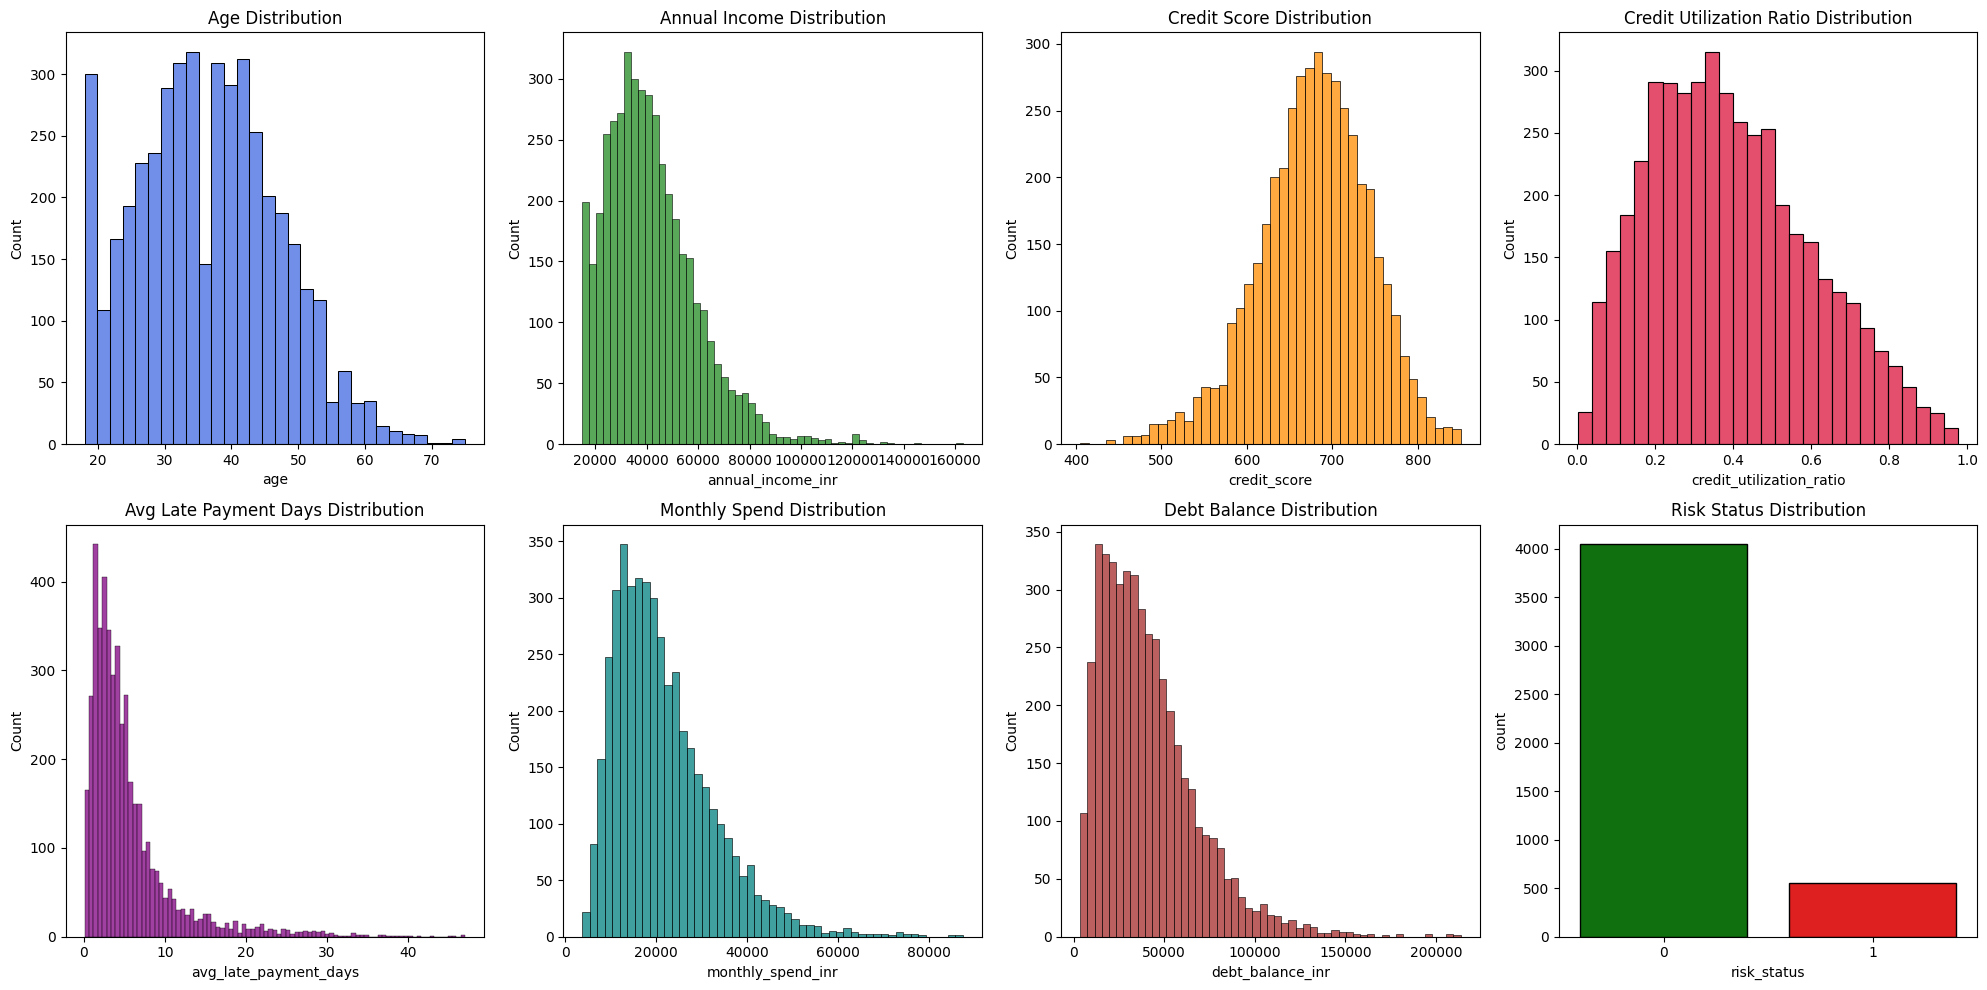

In [7]:
fig , ax = plt.subplots( 2 , 4 , figsize = (20 , 10))

sns.histplot(df['age'] , color = 'royalblue' , edgecolor = 'black' , ax = ax[0,0])
ax[0,0].set_title('Age Distribution')

sns.histplot(df['annual_income_inr'] , color = 'forestgreen' , edgecolor = 'black' , ax = ax[0,1])
ax[0,1].set_title('Annual Income Distribution')

sns.histplot(df['credit_score'] , color = 'darkorange' , edgecolor = 'black' , ax = ax[0,2])
ax[0,2].set_title('Credit Score Distribution')

sns.histplot(df['credit_utilization_ratio'] , color = 'crimson' , edgecolor = 'black' , ax = ax[0,3])
ax[0,3].set_title('Credit Utilization Ratio Distribution')

sns.histplot(df['avg_late_payment_days'] , color = 'purple' , edgecolor = 'black' , ax = ax[1,0])
ax[1,0].set_title('Avg Late Payment Days Distribution')

sns.histplot(df['monthly_spend_inr'] , color = 'teal' , edgecolor = 'black' , ax = ax[1,1])
ax[1,1].set_title('Monthly Spend Distribution')

sns.histplot(df['debt_balance_inr'] , color = 'brown' , edgecolor = 'black' , ax = ax[1,2])
ax[1,2].set_title('Debt Balance Distribution')

sns.countplot(x='risk_status' , data = df , palette = ['green' , 'Red'] , edgecolor = 'black' , ax = ax[1,3])
ax[1,3].set_title('Risk Status Distribution')


plt.tight_layout()
plt.show()

### According to the above subplots of Histogram, it indicates that Annual Income , Avg Late Payment Days , Monthly Spend and Debt Balance are highly skewed while, Credit score is moderately skewed. There is also class imbalance in Risk Status. 

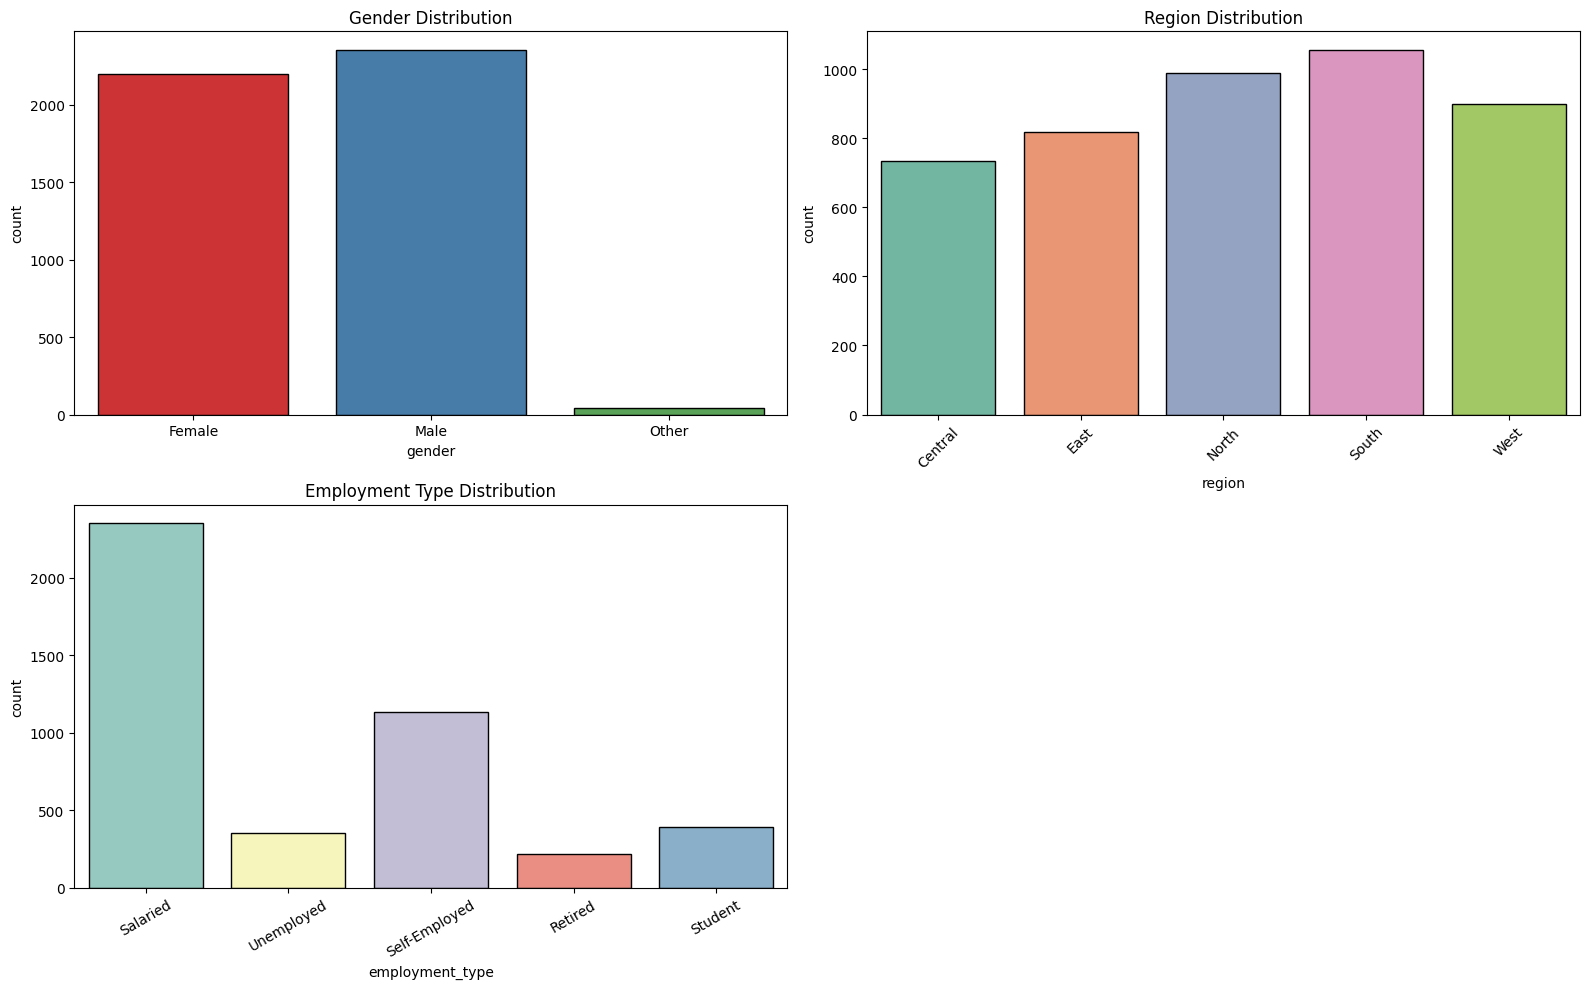

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(x = 'gender' , data = df , palette = 'Set1' , edgecolor = 'black' , ax = ax[0,0])
ax[0,0].set_title('Gender Distribution')

sns.countplot(x = 'region' , data = df , palette = 'Set2' , edgecolor = 'black' , ax = ax[0,1])
ax[0,1].set_title('Region Distribution')
ax[0,1].tick_params(axis = 'x', rotation  = 45)

sns.countplot(x = 'employment_type' , data = df , palette = 'Set3' , edgecolor = 'black' , ax = ax[1,0])
ax[1,0].set_title('Employment Type Distribution')
ax[1,0].tick_params(axis = 'x', rotation = 30)

ax[1,1].axis('off')

plt.tight_layout()
plt.show()

### According to above subplots of countplot, it indicates that Gender and Employment Type has class imbalance.

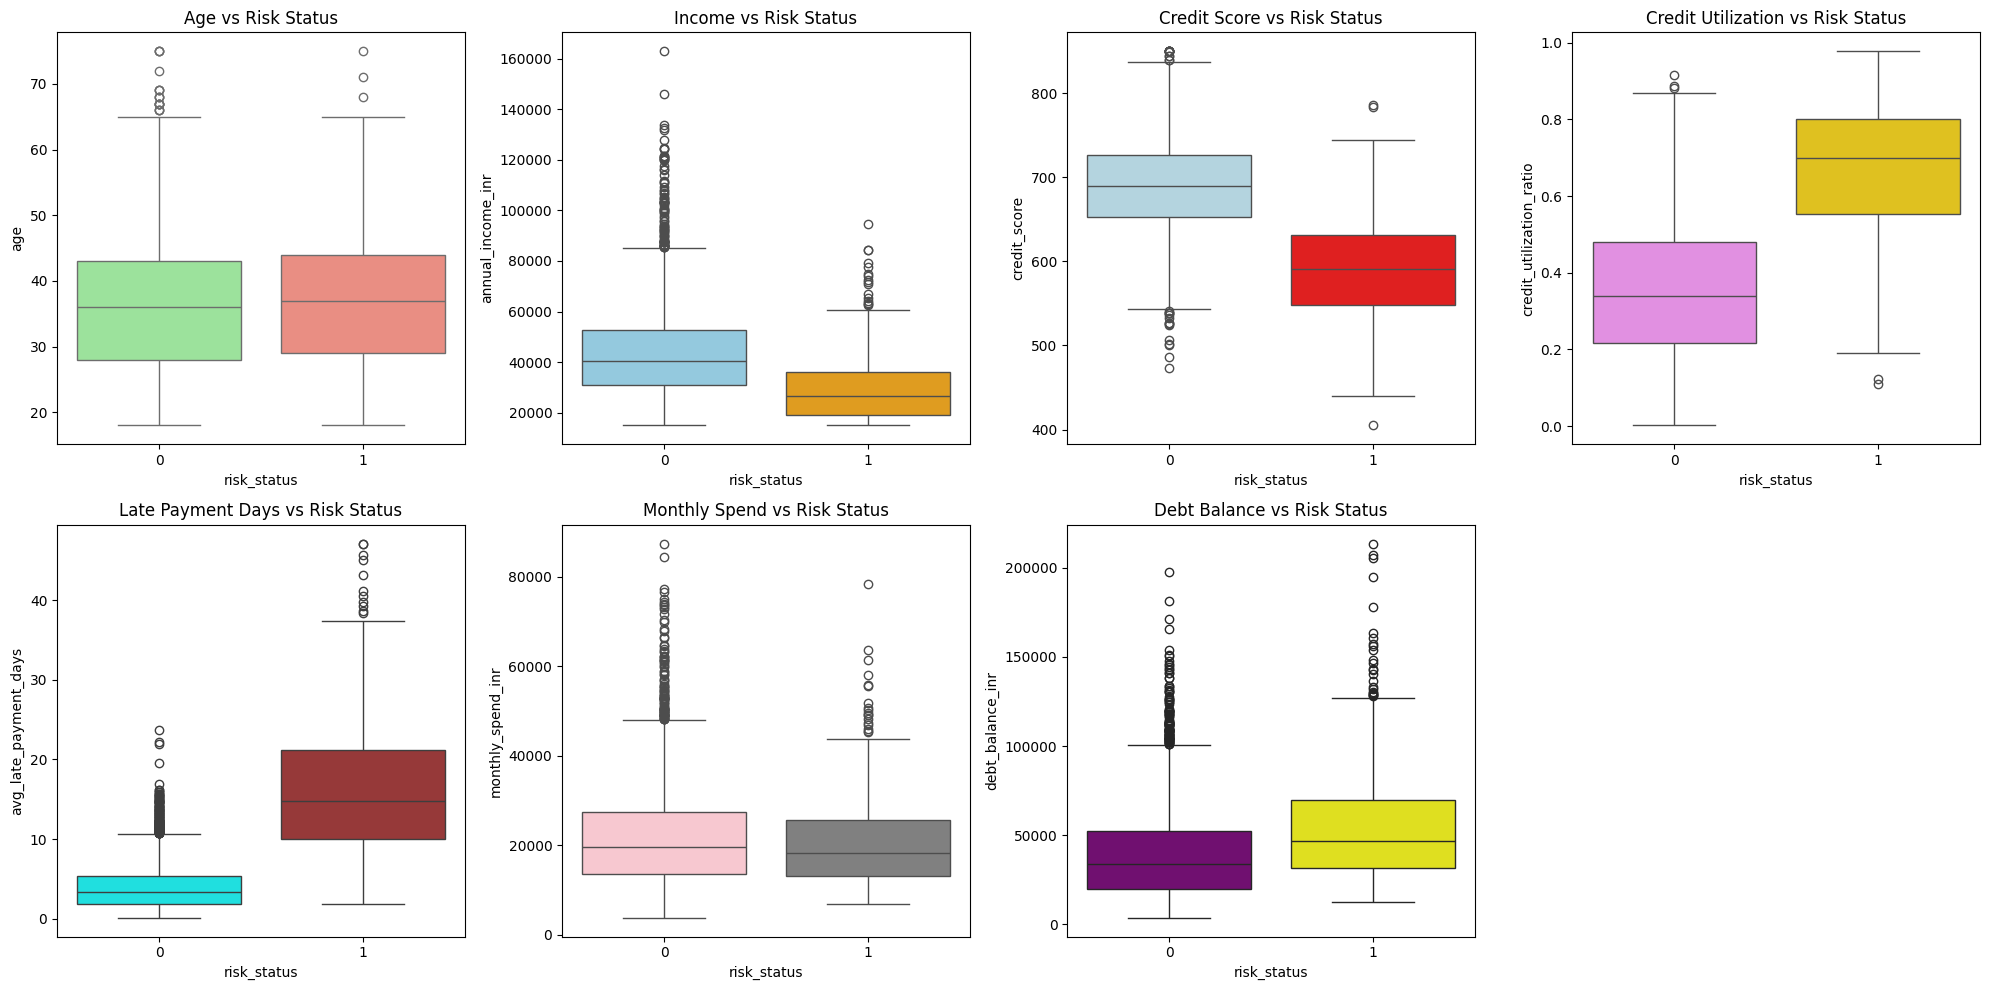

In [9]:
fig, ax = plt.subplots( 2 , 4 , figsize = ( 20 , 10 ))

sns.boxplot( x ='risk_status' , y ='age' , data = df , palette = ['lightgreen', 'salmon'] ,  ax=ax[0,0])
ax[0,0].set_title('Age vs Risk Status')

sns.boxplot(x = 'risk_status' , y = 'annual_income_inr' , data = df , palette = ['skyblue', 'orange'] , ax = ax[0,1])
ax[0,1].set_title('Income vs Risk Status')

sns.boxplot(x = 'risk_status' , y = 'credit_score' , data = df , palette = ['lightblue', 'red'] , ax = ax[0,2])
ax[0,2].set_title('Credit Score vs Risk Status')

sns.boxplot( x = 'risk_status' ,  y = 'credit_utilization_ratio' , data = df ,  palette = ['violet', 'gold'] , ax = ax[0,3])
ax[0,3].set_title('Credit Utilization vs Risk Status')

sns.boxplot(x = 'risk_status' , y = 'avg_late_payment_days' , data = df , palette = ['cyan', 'brown'] , ax = ax[1,0])
ax[1,0].set_title('Late Payment Days vs Risk Status')

sns.boxplot(x = 'risk_status' , y = 'monthly_spend_inr' , data = df , palette = ['pink', 'gray'] , ax = ax[1,1])
ax[1,1].set_title('Monthly Spend vs Risk Status')

sns.boxplot( x = 'risk_status' , y = 'debt_balance_inr' ,  data = df , palette = ['purple' , 'yellow'] , ax = ax[1,2])
ax[1,2].set_title('Debt Balance vs Risk Status')

ax[1,3].axis('off')

plt.tight_layout()
plt.show()

### The boxplot analysis indicates that average late payment days, credit utilization ratio, and credit score consist the clearest separation between low-risk and high-risk customers, suggesting strong prediction power. In opposite, age and monthly spending shows overlap across risk groups, indicating lower prediction power.

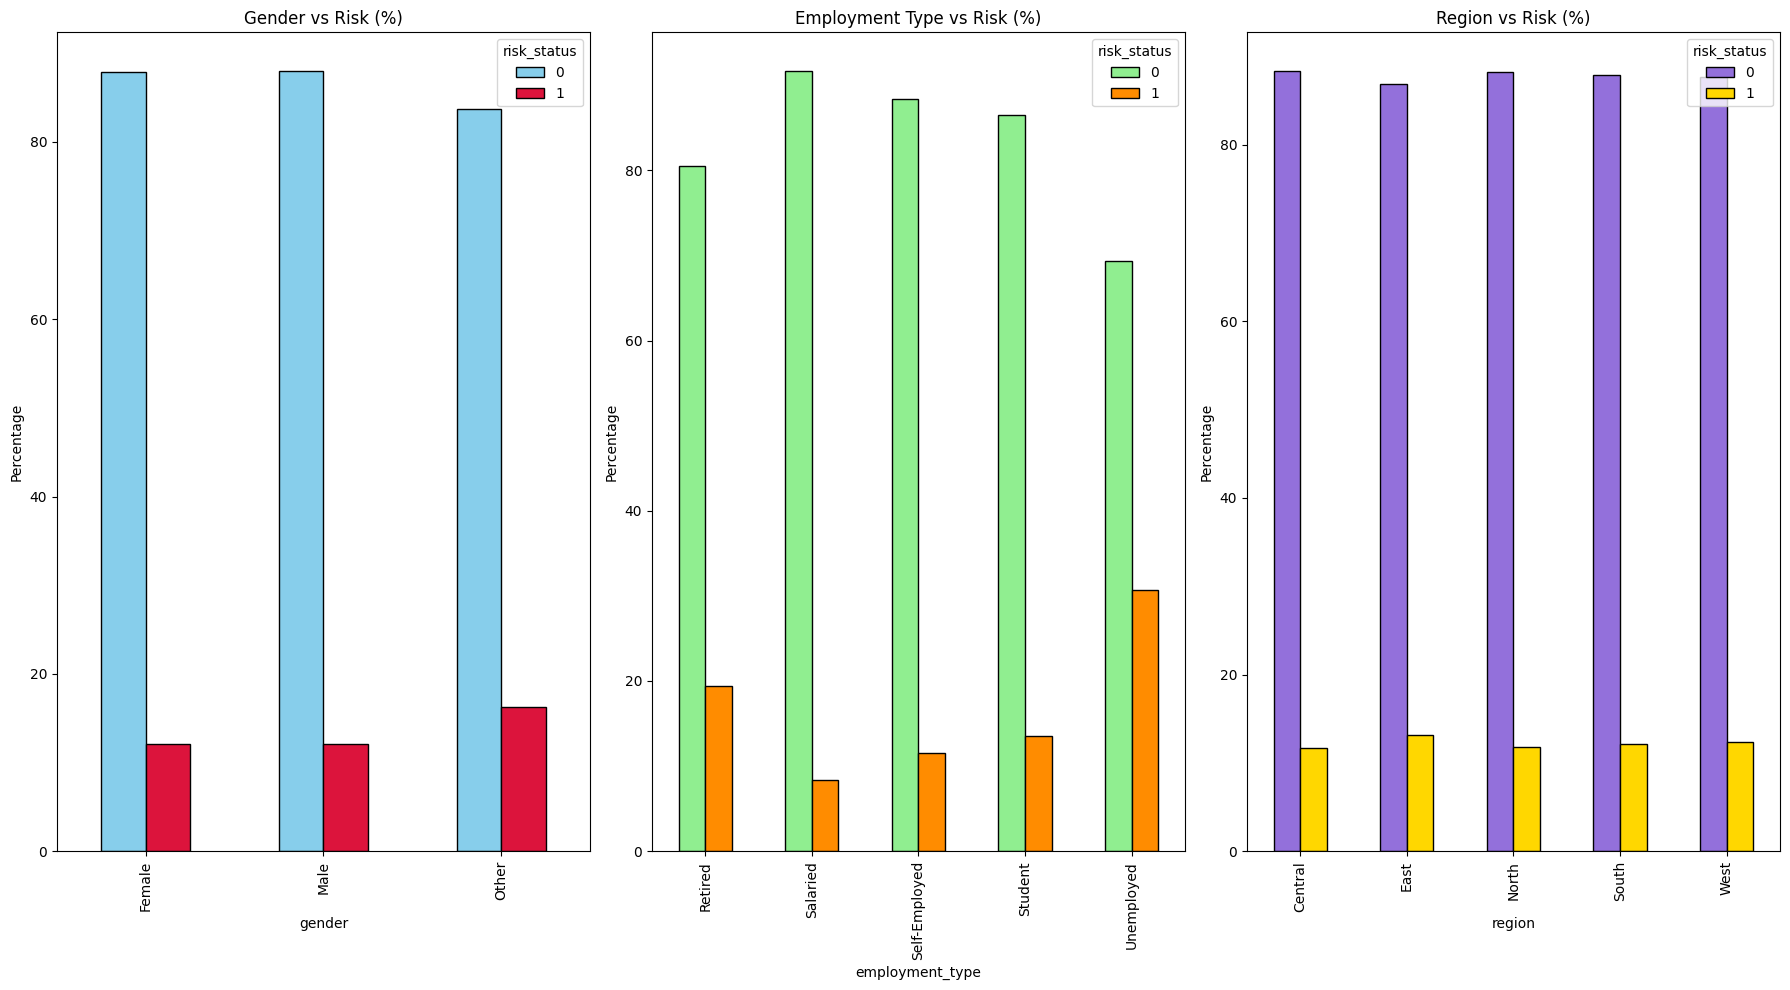

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(18,10))

(pd.crosstab(df['gender'],df['risk_status'],normalize='index')*100).plot(kind='bar',ax=ax[0],color=['skyblue','crimson'],edgecolor='black')
ax[0].set_title('Gender vs Risk (%)')
ax[0].set_ylabel('Percentage')

(pd.crosstab(df['employment_type'],df['risk_status'],normalize='index')*100).plot(kind='bar',ax=ax[1],color=['lightgreen','darkorange'],edgecolor='black')
ax[1].set_title('Employment Type vs Risk (%)')
ax[1].set_ylabel('Percentage')

(pd.crosstab(df['region'],df['risk_status'],normalize='index')*100).plot(kind='bar',ax=ax[2],color=['mediumpurple','gold'],edgecolor='black')
ax[2].set_title('Region vs Risk (%)')
ax[2].set_ylabel('Percentage')

plt.tight_layout()
plt.show()

### The bar plots indicate that gender has little influence on risk classification while, Employment type shows a stronger relationship with risk. Regional analysis reveals a fairly uniform distribution of risk across all regions, suggesting that geographic location has limited prediction power.

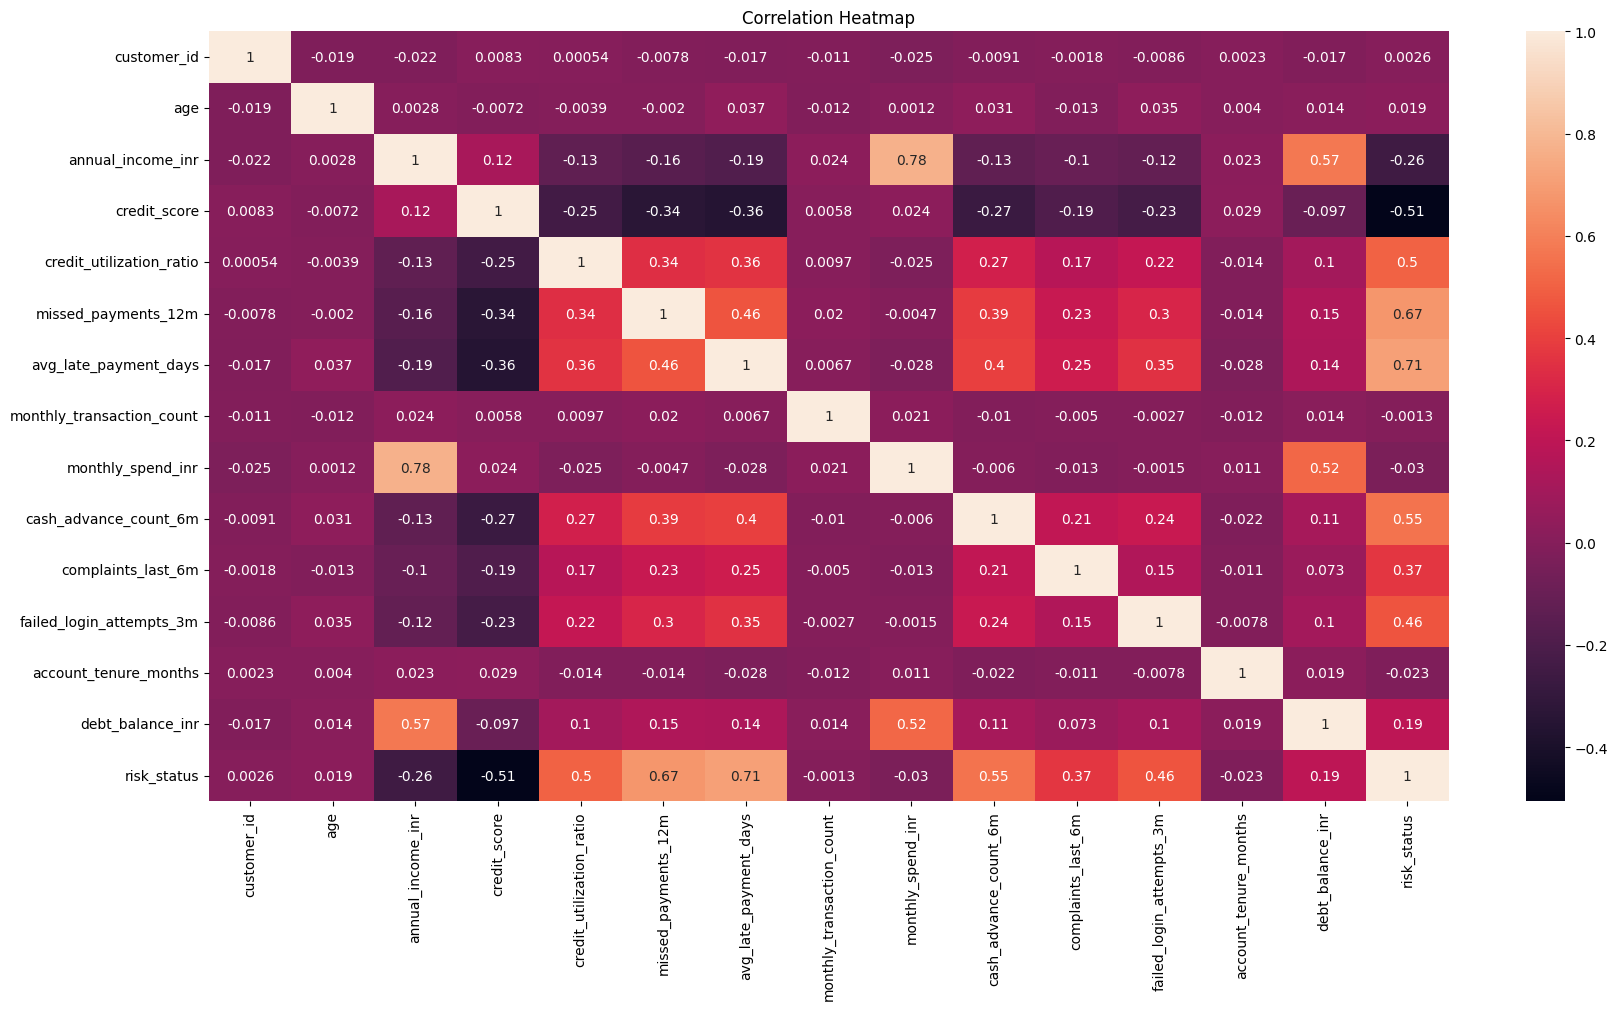

In [11]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### The correlation analysis reveals that average late payment days (0.71),  missed payments in the last 12 months (0.67), cash advance count in the last 6 months (0.55), and credit utilization ratio (0.50) are among the strongest positive predictors of customer risk. Customers exhibiting higher values for these features are more likely to be classified as high-risk. Additionally, failed login attempts (0.46) and customer complaints (0.37) show moderate positive associations with risk status, indicating that behavioral and account activity patterns may also contribute to risk prediction.

## Dropping Unnecessary Features

In [12]:
df = df.drop( columns = ['customer_id' , 'age' , 'account_tenure_months' ,  
    'monthly_spend_inr' , 'monthly_transaction_count' , 'last_transaction_date' ])

### Based on correlation analysis and feature v/s target class boxplots, age, account_tenure_months, monthly_spend_inr, and monthly_transaction_count has very weak relationships with the target variable . Therefore, these features were removed simplify the model. customer_id was dropped because it is a unique identifier and has no prediction information.

## Missing Value Identification

In [13]:
missing_count = df.isnull().sum()
missing_percent = (missing_count/len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)': missing_percent,
})

missing_df

,Missing Count,Missing (%)
gender,0,0.000000
region,102,2.217391
employment_type,144,3.130435
annual_income_inr,166,3.608696
credit_score,216,4.695652
credit_utilization_ratio,147,3.195652
missed_payments_12m,0,0.000000
avg_late_payment_days,0,0.000000
cash_advance_count_6m,0,0.000000
complaints_last_6m,0,0.000000


## Train-Test Split

In [14]:
X = df.drop('risk_status', axis=1)
y = df['risk_status']

In [15]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 10)

## Missing Value Imputation

### Categorical Imputation with 'constant'

In [16]:
cat_cols = ['region' , 'employment_type']

cat_imputer = SimpleImputer(strategy = 'constant' , fill_value = 'Missing')

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])

X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

### It is imputed with strategy = 'constant' because missing values may contain some information.

### Numerical Imputation with KNN.

In [17]:
num_cols =['annual_income_inr','credit_score','credit_utilization_ratio','missed_payments_12m',
    'cash_advance_count_6m','failed_login_attempts_3m','complaints_last_6m','avg_late_payment_days'
    ,'debt_balance_inr']

robust = RobustScaler()

X_train_scaled = robust.fit_transform(X_train[num_cols])

X_test_scaled = robust.transform(X_test[num_cols])

In [18]:
knn = KNNImputer(n_neighbors = 5 , weights = 'distance')

X_train_imputed = knn.fit_transform(X_train_scaled)

X_test_imputed = knn.transform(X_test_scaled)

In [19]:
X_train_org = robust.inverse_transform(X_train_imputed)

X_test_org = robust.inverse_transform(X_test_imputed)

X_train[num_cols] = X_train_org

X_test[num_cols] = X_test_org

## Feature Engineering & Transformation

In [20]:
X_train['debt_to_income_ratio'] = ( X_train['debt_balance_inr'] / X_train['annual_income_inr'] )

X_test['debt_to_income_ratio'] = ( X_test['debt_balance_inr'] / X_test['annual_income_inr'] )

### The feature 'debt_to_income_ratio' is added because those who have high debt and low income are risky while, those who have low debt and high income are less / no risk.

In [21]:
X_train['payment_risk'] = ( X_train['missed_payments_12m'] * X_train['avg_late_payment_days'] )

X_test['payment_risk'] = ( X_test['missed_payments_12m'] * X_test['avg_late_payment_days'] )

### The feature 'payment_risk' is added because it overall tells the missed payment behaviour.

In [22]:
X_train['income_after_debt'] = ( X_train['annual_income_inr'] - X_train['debt_balance_inr'] )

X_test['income_after_debt'] = ( X_test['annual_income_inr'] - X_test['debt_balance_inr'] )

### The feature 'income_after_debt' is added because it tells that if balance is high or enough after paying debt are less risky while, those whose who has less or negative balance after paying debt are high risky.

In [23]:
X_train['annual_income_inr'] = np.log1p( X_train['annual_income_inr'] )
X_test['annual_income_inr'] = np.log1p( X_test['annual_income_inr'] )

X_train['debt_balance_inr'] = np.log1p( X_train['debt_balance_inr'] )
X_test['debt_balance_inr'] = np.log1p( X_test['debt_balance_inr'] )

X_train['avg_late_payment_days'] = np.log1p( X_train['avg_late_payment_days'] )
X_test['avg_late_payment_days'] = np.log1p( X_test['avg_late_payment_days'] )

### The above features are highly positive skewed were log-transformed to reduce skewness and stabilize variance. 

## Encoding

In [24]:
ohe = OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')

train_encoded = ohe.fit_transform( X_train[['gender' , 'region' , 'employment_type']] )

test_encoded = ohe.transform( X_test[['gender' , 'region' , 'employment_type']] )

train_encoded_df = pd.DataFrame(train_encoded,
columns=ohe.get_feature_names_out(['gender' , 'region' , 'employment_type']),index=X_train.index)

test_encoded_df = pd.DataFrame(test_encoded,
columns=ohe.get_feature_names_out(['gender' , 'region' , 'employment_type']),index=X_test.index)

X_train = pd.concat([X_train, train_encoded_df], axis=1)

X_test = pd.concat([X_test, test_encoded_df], axis=1)

X_train.drop(columns=['gender' , 'region' , 'employment_type'],inplace=True)

X_test.drop(columns=['gender' , 'region' , 'employment_type'],inplace=True)

## Feature Scaling

In [25]:
standard = StandardScaler()

X_train[num_cols] = standard.fit_transform(X_train[num_cols])
X_test[num_cols] = standard.transform(X_test[num_cols])

## Logistic Regression

In [26]:
Logistic_model = LogisticRegression( random_state = 10)

Logistic_model.fit(X_train , y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",10
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [27]:
y_pred_Logistic = Logistic_model.predict(X_test)

In [28]:
print(classification_report(y_test , y_pred_Logistic))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       812
           1       1.00      0.98      0.99       108

    accuracy                           1.00       920
   macro avg       1.00      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



In [29]:
tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(y_test, y_pred_Logistic).ravel()

print("True Positive :", tp_lr)
print("False Negative:", fn_lr)
print("False Positive:", fp_lr)
print("True Negative :", tn_lr)

True Positive : 106
False Negative: 2
False Positive: 0
True Negative : 812


In [30]:
print("Precision :", precision_score(y_test, y_pred_Logistic))
print("Recall    :", recall_score(y_test, y_pred_Logistic))
print("Test F1 Score  :", f1_score(y_test, y_pred_Logistic))

Precision : 1.0
Recall    : 0.9814814814814815
Test F1 Score  : 0.9906542056074766


### Stratified K-Fold Cross-Validation

In [31]:
lr_skf = StratifiedKFold( n_splits = 5 , shuffle = True , random_state = 10)

lr_skf_scores = cross_val_score( Logistic_model , X_train , y_train , cv = lr_skf , scoring = 'f1' )

print("F1 Scores for each fold:", lr_skf_scores)
print("Mean F1 Score:", lr_skf_scores.mean())

F1 Scores for each fold: [0.98305085 0.97175141 0.99447514 0.97777778 0.98888889]
Mean F1 Score: 0.9831888129350439


### Logistic Regression achieved excellent classification performance with 100% precision, 98.15% recall, and a 99.07% F1-score. The high mean cross-validation F1-score (98.32%) further indicates that the model generalizes well and produces stable results across different folds.

In [32]:
df['risk_status'].value_counts(normalize = True) * 100

risk_status
0    87.891304
1    12.108696
Name: proportion, dtype: float64

### There is High Imbalanced class in the Dataset. 

## Logistic Regression + SMOTE : Synthetic Minority Over Sampling Technique.

In [33]:
smote = SMOTE(random_state = 10)
 
X_train_smote , y_train_smote = smote.fit_resample(X_train , y_train)

In [34]:
print("Before SMOTE : " , y_train.value_counts() )
print("After SMOTE : " , y_train_smote.value_counts() )

Before SMOTE :  risk_status
0    3231
1     449
Name: count, dtype: int64
After SMOTE :  risk_status
0    3231
1    3231
Name: count, dtype: int64


In [35]:
Logistic_model_SMOTE = LogisticRegression()

Logistic_model_SMOTE.fit(X_train_smote , y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_pred_SMOTE_lr = Logistic_model_SMOTE.predict(X_test)

In [37]:
print(classification_report(y_test, y_pred_SMOTE_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       812
           1       0.98      0.98      0.98       108

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



In [38]:
tn_smote_lr, fp_smote_lr, fn_smote_lr, tp_smote_lr = confusion_matrix(y_test, y_pred_SMOTE_lr).ravel()

print("True Positive :", tp_smote_lr)
print("False Negative:", fn_smote_lr)
print("False Positive:", fp_smote_lr)
print("True Negative :", tn_smote_lr)  

True Positive : 106
False Negative: 2
False Positive: 2
True Negative : 810


In [39]:
print("Precision :", precision_score(y_test, y_pred_SMOTE_lr))
print("Recall    :", recall_score(y_test, y_pred_SMOTE_lr))
print("Test F1 Score  :", f1_score(y_test, y_pred_SMOTE_lr))

Precision : 0.9814814814814815
Recall    : 0.9814814814814815
Test F1 Score  : 0.9814814814814815


In [40]:
Pipeline_Smote = Pipeline([('smote' , SMOTE(random_state = 10)) , ('LR' , LogisticRegression())])

smote_skf = StratifiedKFold( n_splits = 5, shuffle = True , random_state = 10)

smote_skf_scores = cross_val_score(Pipeline_Smote , X_train , y_train , cv = smote_skf , scoring = 'f1')

print('F1 Scores for each fold : ' , smote_skf_scores)
print('Mean F1 Scores : ' , smote_skf_scores.mean())

F1 Scores for each fold :  [0.97802198 0.96629213 0.98360656 0.96174863 0.98901099]
Mean F1 Scores :  0.9757360586242516


### Applying SMOTE, balanced the class distribution before training Logistic Regression. However, the model's performance did not improve compared to the baseline. Precision decreased from 100% to 98.15%, while recall remained unchanged at 98.15%. Both the F1-score and cross-validation performance decreased slightly, indicating that the original dataset already contained sufficient information to accurately classify the minority class without oversampling.

## Decision Tree Classifier

In [41]:
DTC_model = DecisionTreeClassifier(random_state = 10 )

DTC_model.fit(X_train , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",10
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [42]:
y_pred_dtc = DTC_model.predict(X_test)

In [43]:
print(classification_report(y_test , y_pred_dtc))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       812
           1       0.97      0.94      0.95       108

    accuracy                           0.99       920
   macro avg       0.98      0.97      0.97       920
weighted avg       0.99      0.99      0.99       920



In [44]:
tn_dtc, fp_dtc, fn_dtc, tp_dtc = confusion_matrix(y_test, y_pred_dtc).ravel()

print("True Positive :", tp_dtc)
print("False Negative:", fn_dtc)
print("False Positive:", fp_dtc)
print("True Negative :", tn_dtc)    

True Positive : 101
False Negative: 7
False Positive: 3
True Negative : 809


In [45]:
print('Recall : ' , recall_score(y_test , y_pred_dtc))
print('Precision : ' , precision_score(y_test , y_pred_dtc))
print('Test F1 : ' , f1_score(y_test , y_pred_dtc))

Recall :  0.9351851851851852
Precision :  0.9711538461538461
Test F1 :  0.9528301886792453


### Stratified K-Fold

In [46]:
dtc_skf = StratifiedKFold( n_splits = 5 , shuffle = True , random_state = 10 )

dtc_skf_scores = cross_val_score( DTC_model , X_train , y_train , cv = dtc_skf , scoring = 'f1' )

print("F1 Scores for each fold:", dtc_skf_scores)
print("Mean F1 Score:", dtc_skf_scores.mean())

F1 Scores for each fold: [0.9273743  0.93922652 0.94972067 0.96666667 0.92045455]
Mean F1 Score: 0.9406885407050535


### The Decision Tree Classifier achieved significant classification performance with 97.12% precision, 93.52% recall, and a 95.28% F1-score. The mean cross-validation F1-score of 94.07% indicates good generalization across different data splits. However, compared to Logistic Regression, the Decision Tree showed lower recall and F1-score, suggesting that the linear decision boundary of Logistic Regression was better.

## Random Forest Classifier

In [47]:
RFC_model = RandomForestClassifier(random_state = 10)

RFC_model.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [48]:
y_pred_rfc = RFC_model.predict(X_test)

In [49]:
print(classification_report(y_test , y_pred_rfc))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       812
           1       1.00      0.95      0.98       108

    accuracy                           0.99       920
   macro avg       1.00      0.98      0.99       920
weighted avg       0.99      0.99      0.99       920



In [50]:
tn_rfc, fp_rfc, fn_rfc, tp_rfc = confusion_matrix(y_test, y_pred_rfc).ravel()

print("True Positive :", tp_rfc)
print("False Negative:", fn_rfc)
print("False Positive:", fp_rfc)
print("True Negative :", tn_rfc) 

True Positive : 103
False Negative: 5
False Positive: 0
True Negative : 812


In [ ]:
print('Recall : ' , recall_score(y_test , y_pred_rfc))
print('Precision : ' , precision_score(y_test , y_pred_rfc))
print('Test F1 : ' , f1_score(y_test , y_pred_rfc))

Recall :  0.9537037037037037
Precision :  1.0
Test F1 :  0.976303317535545


### Stratified K-Fold

In [52]:
rfc_skf = StratifiedKFold( n_splits = 5 , shuffle = True , random_state = 10 )

rfc_skf_scores = cross_val_score( RFC_model , X_train , y_train , cv = rfc_skf , scoring = 'f1' )

print("F1 Scores for each fold:", rfc_skf_scores)
print("Mean F1 Score:", rfc_skf_scores.mean())

F1 Scores for each fold: [0.96551724 0.97175141 0.97777778 0.98305085 0.98305085]
Mean F1 Score: 0.9762296253003442


### The Random Forest Classifier achieved excellent classification performance with 100% precision, 95.37% recall, and a 97.63% F1-score. The mean cross-validation F1-score of 97.62% indicates stable and reliable performance across different data splits. Although Random Forest performed exceptionally well, Logistic Regression achieved a slightly higher recall and F1-score.

## Final Comparison

In [54]:
Metric_Results = pd.DataFrame({
    'Model' : ['Logistic Regression' , 'Logistic Regression with SMOTE' 
                , 'Decision Tree Classifier' , 'Random Forest Classifier'],
    'TP' : [tp_lr , tp_smote_lr , tp_dtc , tp_rfc],
    'FN' : [fn_lr , fn_smote_lr , fn_dtc , fn_rfc],
    'FP' : [fp_lr , fp_smote_lr , fp_dtc , fp_rfc],
    'TN' : [tn_lr , tn_smote_lr , tn_dtc , tn_rfc]
})

Metric_Results

,Model,TP,FN,FP,TN
0,Logistic Regression,106,2,0,812
1,Logistic Regression with SMOTE,106,2,2,810
2,Decision Tree Classifier,101,7,3,809
3,Random Forest Classifier,103,5,0,812


In [55]:
Results = pd.DataFrame({
    'Model' : ['Logistic Regression' , 'Logistic Regression with SMOTE' 
                , 'Decision Tree Classifier' , 'Random Forest Classifier'],
    'Precision' : [precision_score(y_test, y_pred_Logistic) , precision_score(y_test, y_pred_SMOTE_lr) 
                , precision_score(y_test , y_pred_dtc) , precision_score(y_test , y_pred_rfc)],
    'Recall' : [recall_score(y_test, y_pred_Logistic) , recall_score(y_test, y_pred_SMOTE_lr)
                ,  recall_score(y_test , y_pred_dtc) , recall_score(y_test , y_pred_rfc)],
    'Test F1' : [f1_score(y_test, y_pred_Logistic) , f1_score(y_test, y_pred_SMOTE_lr)
                , f1_score(y_test , y_pred_dtc) , f1_score(y_test , y_pred_rfc)],
    'Avg Stratified CV' : [lr_skf_scores.mean() , smote_skf_scores.mean() , dtc_skf_scores.mean() , rfc_skf_scores.mean()]
})

Results

,Model,Precision,Recall,Test F1,Avg Stratified CV
0,Logistic Regression,1.000000,0.981481,0.990654,0.983189
1,Logistic Regression with SMOTE,0.981481,0.981481,0.981481,0.975736
2,Decision Tree Classifier,0.971154,0.935185,0.952830,0.940689
3,Random Forest Classifier,1.000000,0.953704,0.976303,0.976230


### Logistic Regression achieved the best overall performance with 100% precision, 98.15% recall, a 99.07% F1-score, and the highest mean stratified cross-validation F1-score (98.32%). It correctly identified 106 out of 108 high-risk customers while producing no false positives. Although Random Forest also achieved perfect precision, it missed more high-risk customers. Decision Tree exhibited lower recall and F1-score, and applying SMOTE to Logistic Regression did not improve performance, instead increasing false positives. Therefore, Logistic Regression was selected as the final model due to its superior predictive performance, stability, and simplicity.